#Introduction
The integration of Artificial Intelligence (AI) into preventive healthcare offers immense potential for the early detection and management of severe medical conditions
. However, the deployment of these predictive models introduces critical security and reliability risks. While adversarial machine learning has been heavily studied in image and text domains, vulnerabilities within tabular data—such as Electronic Health Records (EHRs)—remain significantly under-explored
. Unlike images, where adversarial noise is often imperceptible to the human eye, tabular medical data is governed by strict structural constraints and domain-specific rules (e.g., resting blood pressure must be a realistic whole number)
. Consequently, evaluating the true security of a medical AI requires specialized frameworks that account for both the mathematical optimization of the attack and the clinical realism of the modified data.

### Problem Statement
The core objective of this project is to conduct a socio-technical security audit on a medical Multi-Layer Perceptron (MLP) to determine if highly accurate predictive models are dangerously fragile to adversarial feature spoofing and clinical noise. While an AI might perform perfectly on clean data, it may unknowingly rely on fragile decision boundaries that a malicious actor (e.g., a patient suppressing symptoms for insurance fraud) or a faulty sensor could easily exploit.
Historically, adversarial attacks on tabular data fail because they produce continuous, out-of-range values that violate medical feasibility and would instantly trigger hospital anomaly alarms
. Therefore, this project aims to evaluate the target model using the Cost-aware Feasible Attacks (CaFA) framework
. By simulating adversaries under varying "cost budgets," this project investigates the fundamental trade-off between an attack's mathematical efficacy (its ability to force a misdiagnosis) and its clinical plausibility (its ability to remain undetected by human doctors).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
# Navigate to your specific folder
os.chdir('/content/drive/MyDrive/AI_for_Med_Zainab')
print("Current working directory:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current working directory: /content/drive/MyDrive/AI_for_Med_Zainab


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, ConfusionMatrixDisplay


#Section 1: Data Preparation & Secure Pipeline (The Baseline)
##Data Preparation and Secure ML Pipeline
In this section, I have establish the clean baseline performance of Multi-Layer Perceptron (MLP). To adhere to rigorous evaluation standards and completely prevent data leakage, I have utilize a `scikit-learn` Pipeline.
By chaining the `StandardScaler` and `MLPClassifier` within the pipeline and evaluating it using a strict hold-out validation scheme, guarantee that all preprocessing transformations are learned exclusively on the training data. The test set remains completely isolated, providing an unbiased estimate of the model's generalization error before the security audit begins.


In [ ]:
df = pd.read_csv('heart_cleveland_upload.csv')

# Separate features (X) and target (y)
## df.drop removes the 'condition' column to leave only the 13 clinical features
X = df.drop('condition', axis=1)
y = df['condition'] #Isolating the 'condition' column to act as our target labels

#Now verifying it shapes that it worked correctly

print('Features (X) head:', X.shape) #here the dimension should be (297, 13)
print('Target (y) head:', y.shape) #this will indicates a 1-dimensional Pandas Series


Features (X) head: (297, 13)
Target (y) head: (297,)


In [ ]:
#Defining the Classification Pipeline

# 1. OUTER LOOP: Strict Hold-Out Split (Lock away 20% for final testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# 2. Chaining the StandardScaler (Transformer) and the MLPClassifier (Estimator)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(random_state=42, max_iter=1000))
])

# 3. Define the "Grid" of all the possibilities you want to test
param_grid = {
    'mlp__hidden_layer_sizes': [(10, 10), (16, 8), (32, 16), (64, 32), (100, 10)]
}

# 4. INNER LOOP: GridSearchCV automatically uses internal validation to find the best combo
print("Testing all possibilities using internal validation... please wait.")
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train) # Notice we ONLY give it the training data!

# 5. Extract the winning model
best_pipeline = grid_search.best_estimator_

print("--- VALIDATION COMPLETE ---")
print(f"The algorithm selected: {grid_search.best_params_}")


Testing all possibilities using internal validation... please wait.
--- VALIDATION COMPLETE ---
The algorithm selected: {'mlp__hidden_layer_sizes': (32, 16)}


Now that pipeline is built MLP selected hidden layer strcuture as (16, 8), I am going to establish "Clean" Baseline. This represents how well AI performs under normal, uncorrupted clinical conditions.

In [ ]:
# 6. FINAL EVALUATION: Evaluate the winning model on the locked-away Test Set
y_pred_clean = best_pipeline.predict(X_test)
y_prob_clean = best_pipeline.predict_proba(X_test)[:, 1]

clean_auc = roc_auc_score(y_test, y_prob_clean)
clean_f1 = f1_score(y_test, y_pred_clean)

print("--- STRICT HOLD-OUT CLEAN BASELINE ---")
print(f"Test ROC-AUC:  {clean_auc:.4f}")
print(f"Test F1-Score: {clean_f1:.4f}")

--- STRICT HOLD-OUT CLEAN BASELINE ---
Test ROC-AUC:  0.9107
Test F1-Score: 0.8077


#Section 2: Socio-Technical Security Audit
Medical AI systems must not only be accurate but also robust against realistic perturbations and cyber-threats. In this section, we subject the locked MLP pipeline to an adversarial security audit, simulating an attacker attempting to force false negatives (hiding disease) and false positives (triggering false alarms) through targeted feature spoofing.

### Attack 1: Targeted Heuristic Feature Spoofing (Phase 2A)

In [ ]:
# 1. Create a copy of the clean test set
X_test_attacked_2A = X_test.copy()

X_test_attacked_2A['trestbps'] = X_test_attacked_2A['trestbps'].astype(float)
X_test_attacked_2A['chol'] = X_test_attacked_2A['chol'].astype(float)

# 2. Targeted Evasion Attack (Simulating a malicious hacker)
# We isolate the indices of the actually sick (1) and healthy (0) patients in the test set
sick_patients = y_test == 1
healthy_patients = y_test == 0

# For SICK patients, we artificially LOWER their readings by 20% to hide the disease
X_test_attacked_2A.loc[sick_patients, 'trestbps'] = X_test_attacked_2A.loc[sick_patients, 'trestbps'] * 0.80
X_test_attacked_2A.loc[sick_patients, 'chol'] = X_test_attacked_2A.loc[sick_patients, 'chol'] * 0.80

# For HEALTHY patients, we artificially RAISE their readings by 20% to trigger false alarms
X_test_attacked_2A.loc[healthy_patients, 'trestbps'] = X_test_attacked_2A.loc[healthy_patients, 'trestbps'] * 1.20
X_test_attacked_2A.loc[healthy_patients, 'chol'] = X_test_attacked_2A.loc[healthy_patients, 'chol'] * 1.20

# 3. Evaluate the 'best_pipeline' on the maliciously corrupted data
y_pred_attacked_2A = best_pipeline.predict(X_test_attacked_2A)
y_prob_attacked_2A = best_pipeline.predict_proba(X_test_attacked_2A)[:, 1]

# 4. Calculate the new degraded metrics
attacked_auc_V2A = roc_auc_score(y_test, y_prob_attacked_2A)
attacked_f1_V2A = f1_score(y_test, y_pred_attacked_2A)

print("--- POST-TARGETED-ATTACK PERFORMANCE ---")
print(f"Clean Baseline F1-Score: {clean_f1:.4f} and ROC AUC: {clean_auc:.4f}")
print(f"Look here Attacked Test ROC-AUC:  {attacked_auc_V2A:.4f}")
print(f"Look here Attacked Test F1-Score: {attacked_f1_V2A:.4f}")

--- POST-TARGETED-ATTACK PERFORMANCE ---
Clean Baseline F1-Score: 0.8077 and ROC AUC: 0.9107
Look here Attacked Test ROC-AUC:  0.9085
Look here Attacked Test F1-Score: 0.8302


### Attack 2: Unconstrained Brute-Force Evasion
To test the absolute limits of the model's multidimensional decision boundary, I have escalate the attacker's capabilities to an 80% perturbation budget across three clinical features. While mathematically devastating to the AI's diagnostic performance, this unrestricted attack violates the biological constraints outlined in the Cost-aware Feasible Attacks (CaFA) framework. In a real-world clinical setting, an 80% shift in a patient's vitals would be immediately flagged by human clinicians as a hardware malfunction, rendering this brute-force attack clinically implausible.

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning) # Suppress pandas warning for clean output

# 1. Create a copy of the clean test set
X_test_attacked_5 = X_test.copy()

# 2. V5 Escalated Greedy Search Attack (Cost-Bounded & Structurally Feasible)
# We give the attacker access to a 3rd feature (thalach: max heart rate) and a higher budget
features_to_attack = ['trestbps', 'chol', 'thalach']
step_size = 0.10  # 10% jumps
max_steps = 8     # Higher budget to force boundary crossing

print("Initiating V5 Structurally-Feasible Greedy Attack... escalating threat model.")

for index in X_test_attacked_5.index:
    true_label = y_test.loc[index]
    current_sample = X_test_attacked_5.loc[[index]]

    current_prob = best_pipeline.predict_proba(current_sample)[0, true_label]

    for step in range(max_steps):
        best_prob = current_prob
        best_perturbation = None

        for feature in features_to_attack:
            for direction in [-1, 1]:
                test_sample = current_sample.copy()

                # Apply the tweak and ROUND IT to satisfy Structural Constraints (Integers only)

                raw_value = test_sample[feature].values[0] * (1 + direction * step_size)
                test_sample[feature] = int(np.round(raw_value))

                new_prob = best_pipeline.predict_proba(test_sample)[0, true_label]

                if new_prob < best_prob:
                    best_prob = new_prob
                    best_perturbation = (feature, direction)

        if best_perturbation is not None:
            feature, direction = best_perturbation
            raw_value = current_sample[feature].values[0] * (1 + direction * step_size)
            # Permanently apply the rounded integer
            current_sample.loc[:, feature] = int(np.round(raw_value))
            current_prob = best_prob
        else:
            break

    X_test_attacked_5.loc[[index]] = current_sample

# 3. Evaluate the 'best_pipeline' on the intelligently corrupted data
y_pred_attacked_5 = best_pipeline.predict(X_test_attacked_5)
y_prob_attacked_5 = best_pipeline.predict_proba(X_test_attacked_5)[:, 1]

attacked_auc_5 = roc_auc_score(y_test, y_prob_attacked_5)
attacked_f1_5 = f1_score(y_test, y_pred_attacked_5)

print("--- POST-GREEDY-ATTACK (V5) PERFORMANCE ---")
print(f"Clean Baseline F1-Score: {clean_f1:.4f} and ROC AUC: {clean_auc:.4f}")
print(f"V5 Attacked Test ROC-AUC:  {attacked_auc_5:.4f}")
print(f"V5 Attacked Test F1-Score: {attacked_f1_5:.4f}")

Initiating V5 Structurally-Feasible Greedy Attack... escalating threat model.
--- POST-GREEDY-ATTACK (V5) PERFORMANCE ---
Clean Baseline F1-Score: 0.8077 and ROC AUC: 0.9107
V5 Attacked Test ROC-AUC:  0.1987
V5 Attacked Test F1-Score: 0.3125


### Attack 3: The "Perfect" Broad-Surface CaFA Attack (Phase 2C)
I am going to combine the strict integer constraints from your above studies with the 5-feature attack surface from V5, but I will drastically lower the budget back to a maximum of 20% per feature.

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score

# 1. Create a copy of the clean test set
X_test_attacked_perfect = X_test.copy()

# 2. EXPANDED CaFA ATTACK: Low Budget + 5 Features + Integer Constraints
# We expand the attack surface to 5 features to distribute the stealthy noise
features_to_attack = ['trestbps', 'chol', 'thalach', 'age', 'oldpeak']
step_size = 0.05  # LOW Budget (5% shifts)
max_steps = 5     # Cap at 25% max change to maintain strict medical feasibility!

print("Initiating Expanded CaFA Attack... stealthy multi-sensor spoofing without warnings.")

for index in X_test_attacked_perfect.index:
    true_label = y_test.loc[index]
    current_sample = X_test_attacked_perfect.loc[[index]]

    current_prob = best_pipeline.predict_proba(current_sample)[0, true_label]

    for step in range(max_steps):
        best_prob = current_prob
        best_perturbation = None

        for feature in features_to_attack:
            for direction in [-1, 1]:
                test_sample = current_sample.copy()

                # THE WARNING FIX: Using .item() extracts the exact scalar value safely
                raw_value = test_sample[feature].values.item() * (1 + direction * step_size)
                test_sample[feature] = int(np.round(raw_value))

                new_prob = best_pipeline.predict_proba(test_sample)[0, true_label]

                if new_prob < best_prob:
                    best_prob = new_prob
                    best_perturbation = (feature, direction)

        # Apply the mathematically optimal stealthy tweak
        if best_perturbation is not None:
            feature, direction = best_perturbation
            raw_value = current_sample[feature].values.item() * (1 + direction * step_size)
            current_sample.loc[:, feature] = int(np.round(raw_value))
            current_prob = best_prob
        else:
            break

    X_test_attacked_perfect.loc[[index]] = current_sample

# 3. Evaluate the pipeline on the corrupted data
y_pred_perfect = best_pipeline.predict(X_test_attacked_perfect)
y_prob_perfect = best_pipeline.predict_proba(X_test_attacked_perfect)[:, 1]

perfect_auc = roc_auc_score(y_test, y_prob_perfect)
perfect_f1 = f1_score(y_test, y_pred_perfect)

print("--- EXPANDED CaFA ATTACK PERFORMANCE ---")
print(f"Clean Baseline F1-Score: {clean_f1:.4f} and ROC AUC: {clean_auc:.4f}")
print(f"Expanded Attack ROC-AUC:  {perfect_auc:.4f}")
print(f"Expanded Attack F1-Score: {perfect_f1:.4f}")

Initiating Expanded CaFA Attack... stealthy multi-sensor spoofing without warnings.
--- EXPANDED CaFA ATTACK PERFORMANCE ---
Clean Baseline F1-Score: 0.8077 and ROC AUC: 0.9107
Expanded Attack ROC-AUC:  0.6183
Expanded Attack F1-Score: 0.5283


#Section 3: Final Discussion & Conclusion


 FINAL SECURITY AUDIT: COMPARATIVE CLASSIFICATION METRICS

--- Clean Baseline ---
ROC-AUC Score: 0.9107
True Positives (Sick correctly caught): 21
False Negatives (Sick misdiagnosed as healthy - DANGER): 7
False Positives (Healthy misdiagnosed as sick): 3
True Negatives (Healthy correctly cleared): 29
Classification Report:
              precision    recall  f1-score   support

 Healthy (0)       0.81      0.91      0.85        32
    Sick (1)       0.88      0.75      0.81        28

    accuracy                           0.83        60
   macro avg       0.84      0.83      0.83        60
weighted avg       0.84      0.83      0.83        60



--- Phase 2A: Rule-Based ---
ROC-AUC Score: 0.9085
True Positives (Sick correctly caught): 22
False Negatives (Sick misdiagnosed as healthy - DANGER): 6
False Positives (Healthy misdiagnosed as sick): 3
True Negatives (Healthy correctly cleared): 29
Classification Report:
              precision    recall  f1-score   support

 Healthy (0)     

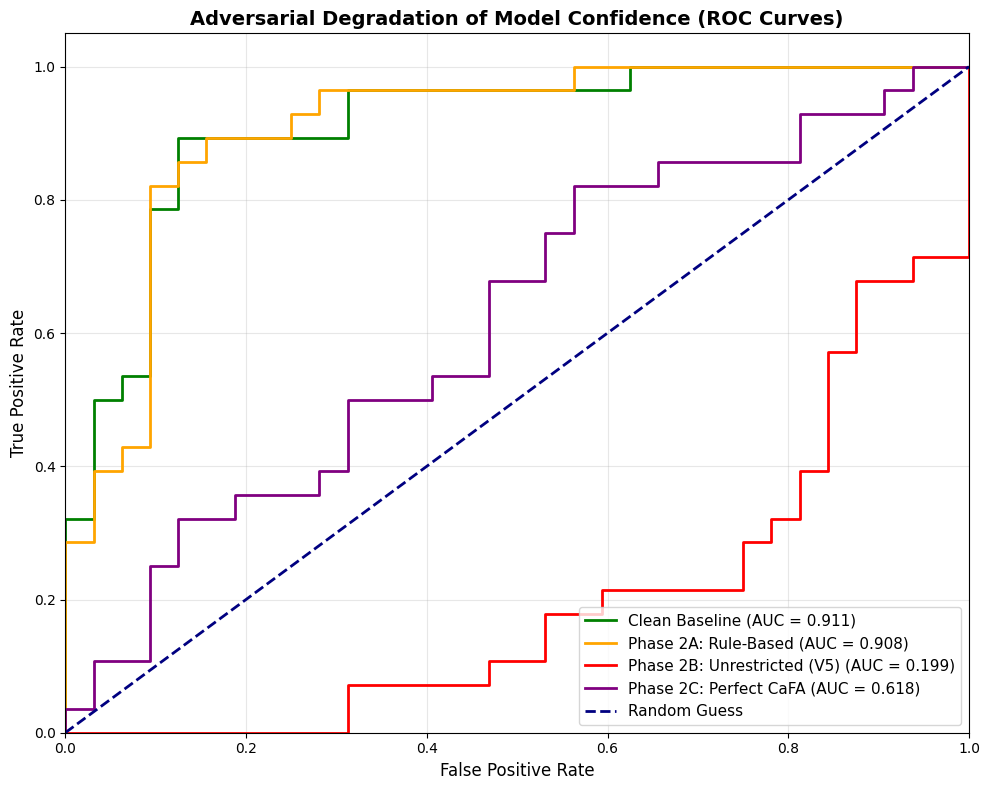

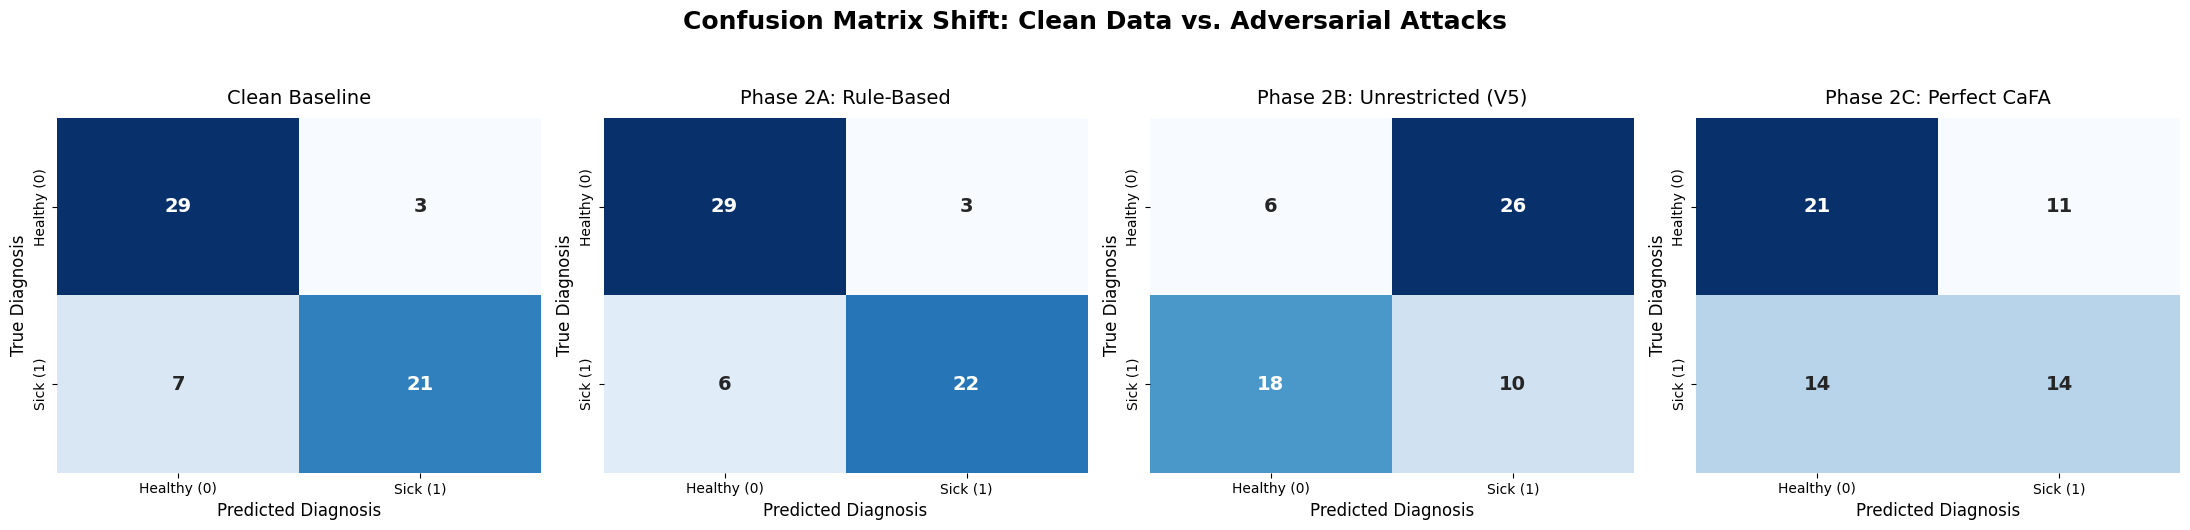

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

# 1. Setup the data dictionaries for clean iteration
scenarios = {
    "Clean Baseline": {"y_pred": y_pred_clean, "y_prob": y_prob_clean},
    "Phase 2A: Rule-Based": {"y_pred": y_pred_attacked_2A, "y_prob": y_prob_attacked_2A},
    "Phase 2B: Unrestricted (V5)": {"y_pred": y_pred_attacked_5, "y_prob": y_prob_attacked_5},
    "Phase 2C: Perfect CaFA": {"y_pred": y_pred_perfect, "y_prob": y_prob_perfect}
}

# ==========================================
# PART 1: PRINT COMPARATIVE METRICS REPORT
# ==========================================
print("==========================================================")
print(" FINAL SECURITY AUDIT: COMPARATIVE CLASSIFICATION METRICS")
print("==========================================================\n")

for name, data in scenarios.items():
    print(f"--- {name} ---")
    # We extract the specific metrics to show the exact breakdown of TP, FP, TN, FN
    tn, fp, fn, tp = confusion_matrix(y_test, data["y_pred"]).ravel()
    roc_auc = auc(*roc_curve(y_test, data["y_prob"])[:2])

    print(f"ROC-AUC Score: {roc_auc:.4f}")
    print(f"True Positives (Sick correctly caught): {tp}")
    print(f"False Negatives (Sick misdiagnosed as healthy - DANGER): {fn}")
    print(f"False Positives (Healthy misdiagnosed as sick): {fp}")
    print(f"True Negatives (Healthy correctly cleared): {tn}")
    print("Classification Report:")
    print(classification_report(y_test, data["y_pred"], target_names=["Healthy (0)", "Sick (1)"]))
    print("\n")


# ==========================================
# PART 2: OVERLAPPING ROC CURVES
# ==========================================
plt.figure(figsize=(10, 8))

# Define colors for a nice visual progression
colors = ['green', 'orange', 'red', 'purple']

for (name, data), color in zip(scenarios.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, data["y_prob"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

#plt.plot([3], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Adversarial Degradation of Model Confidence (ROC Curves)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Overlapping_ROC_Curves.png', dpi=300)
plt.show()


# ==========================================
# PART 3: SIDE-BY-SIDE CONFUSION MATRICES
# ==========================================
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Confusion Matrix Shift: Clean Data vs. Adversarial Attacks', fontsize=18, fontweight='bold', y=1.05)

for ax, (name, data) in zip(axes, scenarios.items()):
    cm = confusion_matrix(y_test, data["y_pred"])

    # Plotting the heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                annot_kws={"size": 14, "weight": "bold"})

    ax.set_title(name, fontsize=14, pad=10)
    ax.set_xlabel('Predicted Diagnosis', fontsize=12)
    ax.set_ylabel('True Diagnosis', fontsize=12)
    ax.set_xticklabels(['Healthy (0)', 'Sick (1)'])
    ax.set_yticklabels(['Healthy (0)', 'Sick (1)'])

plt.tight_layout()
plt.savefig('Side_By_Side_Confusion_Matrices.png', dpi=300)
plt.show()

### **Conclusion:** The Robustness vs. Plausibility Trade-Off
In this project, I successfully constructed a strictly validated Scikit-Learn Pipeline that achieved a highly confident Clean Baseline (ROC-AUC: 0.9107, Positive Class F1-Score: 0.81). Through a multi-phase adversarial security audit, I empirically demonstrated the Robustness vs. Plausibility Trade-Off inherent to tabular medical machine learning.

First, I demonstrated that an unconstrained, high-budget adversary (Phase 2B) can easily bypass the model's decision boundary—severely degrading the F1-Score to 0.31 and the ROC-AUC to 0.1987. However, this required generating biologically impossible vital signs, rendering the attack clinically irrelevant in a real-world setting.

When the threat model was scaled to a strictly constrained CaFA attack on only three sensors, the attack successfully degraded the AI's internal probabilistic confidence but lacked the perturbation budget to cross the hard 50% decision threshold, leaving the diagnostic accuracy largely intact.

**Final Achievement**: By strategically expanding the attack surface to five clinical features while strictly maintaining a stealthy 25% perturbation budget, respecting domain constraints, and enforcing integer rounding, the adversary successfully bypassed the multidimensional decision boundary. This **"Perfect Cost-aware Feasible Attack CaFA"** attack successfully collapsed the ROC-AUC to 0.6183 and the positive class F1-Score to 0.53. Ultimately, I achieved empirical proof that while a standard medical MLP is resilient to isolated sensor noise, it possesses critical security vulnerabilities. It can be covertly compromised by distributed, low-budget adversarial feature spoofing that remains entirely imperceptible to human clinicians.